In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline


In [5]:
dataset = pd.read_csv('Algerian_forest_fires_dataset.csv')

In [6]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [7]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 38.0 KB


## data cleaning


In [10]:
dataset.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

In [11]:
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [15]:
dataset["Region"] = 0

dataset.loc[:122, "Region"] = 0
dataset.loc[123:, "Region"] = 1

dataset.drop([122, 123], inplace=True)

dataset.reset_index(drop=True, inplace=True)
df = dataset.copy()

In [16]:
df[["Region"]].astype('int').inplace=True

In [17]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [20]:
###remove the null values
df.dropna().inplace = True


In [21]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        1
Region         0
dtype: int64

we haev to find that another atrributes that have null values and remove them as well.

In [34]:

df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0
5,6,6,2012,31,67,14,0,82.6,5.8,22.2,3.1,7,2.5,fire,0
6,7,6,2012,33,54,13,0,88.2,9.9,30.5,6.4,10.9,7.2,fire,0
7,8,6,2012,30,73,15,0,86.6,12.1,38.3,5.6,13.5,7.1,fire,0
8,9,6,2012,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,not fire,0
9,10,6,2012,28,79,12,0,73.2,9.5,46.3,1.3,12.6,0.9,not fire,0


In [35]:
df.dropna(inplace=True)

In [36]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [37]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='str')

In [38]:
## i need to remove spaces in column names
df.columns = df.columns.str.replace(' ',"") # or df.columns = df.columns.str.strip()

In [39]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [46]:
## change the required columns as integer
df[['day', 'month', 'year', 'Region', 'Temperature','RH',"Ws"]] = df[['day', 'month', 'year', 'Region','Temperature','RH',"Ws"]].astype(int)

In [47]:
df.sample(2)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
143,23,6,2012,33,59,16,0.8,74.2,7,8.3,1.6,6.7,0.8,not fire,1
57,28,7,2012,33,76,15,0,86.5,24.4,117.8,5.6,32.1,11.3,fire,0


In [48]:
df.info()

<class 'pandas.DataFrame'>
Index: 242 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          242 non-null    int64
 1   month        242 non-null    int64
 2   year         242 non-null    int64
 3   Temperature  242 non-null    int64
 4   RH           242 non-null    int64
 5   Ws           242 non-null    int64
 6   Rain         242 non-null    str  
 7   FFMC         242 non-null    str  
 8   DMC          242 non-null    str  
 9   DC           242 non-null    str  
 10  ISI          242 non-null    str  
 11  BUI          242 non-null    str  
 12  FWI          242 non-null    str  
 13  Classes      242 non-null    str  
 14  Region       242 non-null    int64
dtypes: int64(7), str(8)
memory usage: 37.7 KB


In [51]:
#### chanign ghe other columns to float
df[['FFMC', 'DMC','Rain','DC', 'ISI', 'BUI', 'FWI']] = df[['FFMC', 'DMC', 'Rain','DC', 'ISI', 'BUI', 'FWI']].astype(float)

In [52]:
df.info()

<class 'pandas.DataFrame'>
Index: 242 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          242 non-null    int64  
 1   month        242 non-null    int64  
 2   year         242 non-null    int64  
 3   Temperature  242 non-null    int64  
 4   RH           242 non-null    int64  
 5   Ws           242 non-null    int64  
 6   Rain         242 non-null    float64
 7   FFMC         242 non-null    float64
 8   DMC          242 non-null    float64
 9   DC           242 non-null    float64
 10  ISI          242 non-null    float64
 11  BUI          242 non-null    float64
 12  FWI          242 non-null    float64
 13  Classes      242 non-null    str    
 14  Region       242 non-null    int64  
dtypes: float64(7), int64(7), str(1)
memory usage: 32.3 KB


In [53]:
###lets save the cleaned dataset
df.to_csv("Algerian_forest_fires_dataset_cleaned.csv", index=False)
#index= False is used to avoid adding an extra index column in the csv file.

## EDA


In [89]:
df_copy = df.drop(['day','month','year'], axis=1)

In [92]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [93]:
## Encoding the target variable
df_copy["Classes"] = np.where(df_copy["Classes"].str.contains('not fire'),0,1)

AttributeError: Can only use .str accessor with string values, not integer

In [ ]:
import numpy as np

df_copy["Classes"] = np.where(
    df_copy["Classes"].astype(str).str.contains("not fire", case=False),
    0,
    1
)

The code is encoding the target variable "Classes" in the DataFrame `df_copy`. It uses the `np.where` function to check if the "Classes" column contains the string "not fire". If it does, it assigns a value of 0 (indicating "not fire"), and if it does not, it assigns a value of 1 (indicating "fire"). The `case=False` argument makes the string comparison case-insensitive. This way, all entries in the "Classes" column are converted to binary values, where 0 represents "not fire" and 1 represents "fire".

In [ ]:
df_copy.isnull().sum()

Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [94]:
df_copy["Classes"].value_counts()

Classes
1    137
0    105
Name: count, dtype: int64

In [95]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'RH'}>, <Axes: title={'center': 'Ws'}>],
       [<Axes: title={'center': 'Rain'}>,
        <Axes: title={'center': 'FFMC'}>,
        <Axes: title={'center': 'DMC'}>],
       [<Axes: title={'center': 'DC'}>, <Axes: title={'center': 'ISI'}>,
        <Axes: title={'center': 'BUI'}>],
       [<Axes: title={'center': 'FWI'}>,
        <Axes: title={'center': 'Classes'}>,
        <Axes: title={'center': 'Region'}>]], dtype=object)

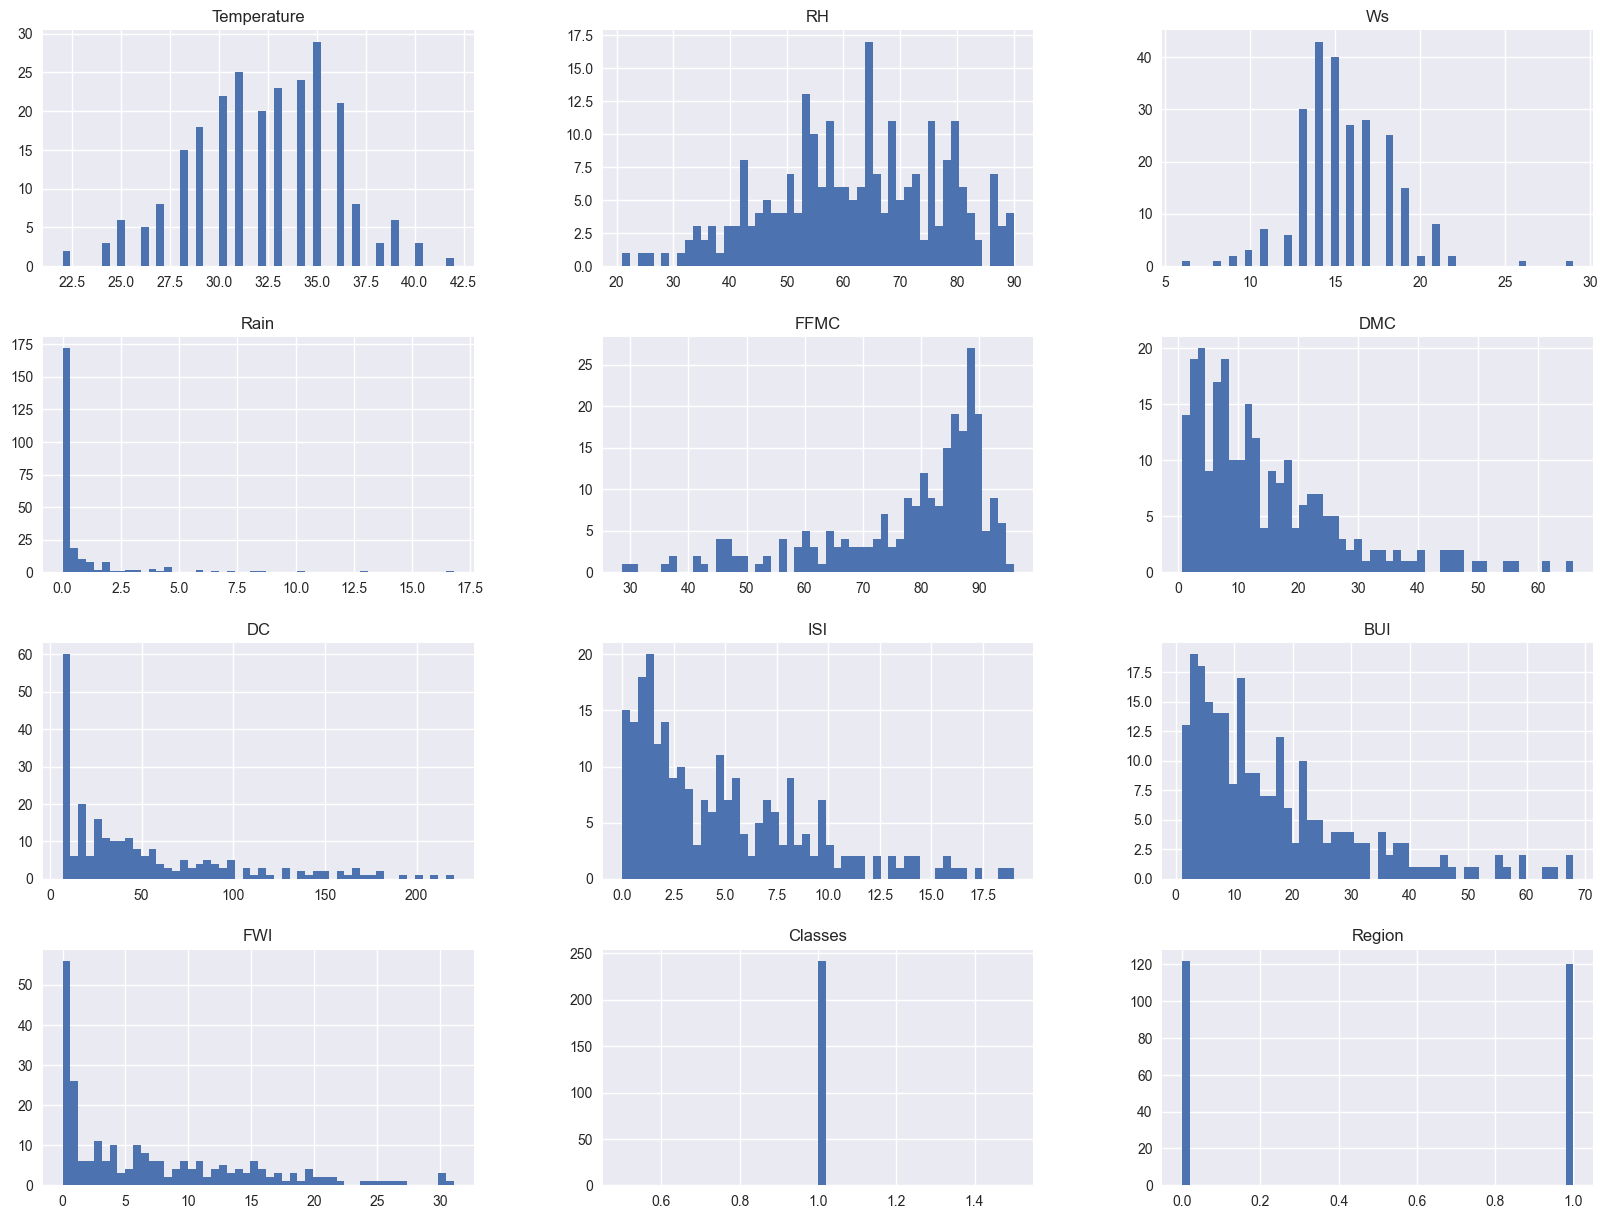

In [ ]:
### plot density pplot for all the features
plt.style.use('seaborn-v0_8')
df_copy.hist(bins = 50,figsize=(20,15))


In [96]:
##percentages of piechart
df_copy["Classes"].value_counts(normalize=True)*100

Classes
1    56.61157
0    43.38843
Name: proportion, dtype: float64

([<matplotlib.patches.Wedge at 0x1b294d15290>,
 [Text(-1.0763566478040756, -0.22683995840233595, 'Fire'),
  Text(1.0763566279730916, 0.22684005250042552, 'Not Fire')],
 [Text(-0.5871036260749503, -0.12373088640127414, '56.6%'),
  Text(0.5871036152580499, 0.12373093772750482, '43.4%')])

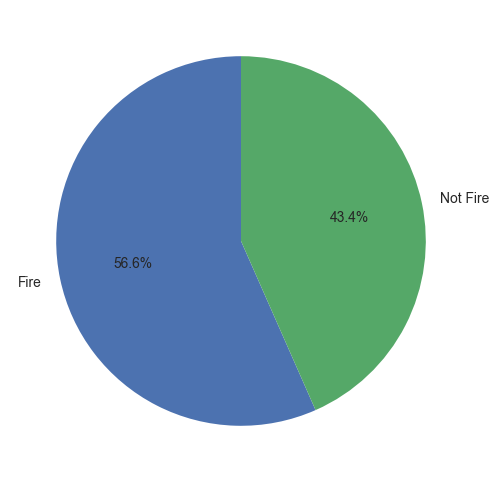

In [102]:
##plotting pie chart
classLabels = ['Fire', 'Not Fire']
plt.figure(figsize=(6,6))
plt.pie(df_copy["Classes"].value_counts(), labels=classLabels, autopct='%2.1f%%', startangle=90)

In [104]:
## corelation
df_copy.corr()


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651791,-0.285644,-0.326499,0.679270,0.486494,0.376720,0.604948,0.460533,0.567506,0.517203,0.270295
RH,-0.651791,1.000000,0.248148,0.222604,-0.644536,-0.407180,-0.225293,-0.686103,-0.352357,-0.580109,-0.430794,-0.406348
Ws,-0.285644,0.248148,1.000000,0.171896,-0.175324,-0.005819,0.075031,0.003408,0.026542,0.027768,-0.076262,-0.176928
Rain,-0.326499,0.222604,0.171896,1.000000,-0.546470,-0.289482,-0.298600,-0.348334,-0.300574,-0.325112,-0.380263,-0.039965
FFMC,0.679270,-0.644536,-0.175324,-0.546470,1.000000,0.601527,0.505185,0.738754,0.589881,0.689822,0.768069,0.229726
DMC,0.486494,-0.407180,-0.005819,-0.289482,0.601527,1.000000,0.875511,0.679150,0.982178,0.875405,0.583760,0.196981
DC,0.376720,-0.225293,0.075031,-0.298600,0.505185,0.875511,1.000000,0.506897,0.941809,0.738663,0.509202,-0.075412
ISI,0.604948,-0.686103,0.003408,-0.348334,0.738754,0.679150,0.506897,1.000000,0.642650,0.922613,0.733978,0.268456
BUI,0.460533,-0.352357,0.026542,-0.300574,0.589881,0.982178,0.941809,0.642650,1.000000,0.857449,0.584762,0.093849
FWI,0.567506,-0.580109,0.027768,-0.325112,0.689822,0.875405,0.738663,0.922613,0.857449,1.000000,0.718067,0.201695


<Axes: >

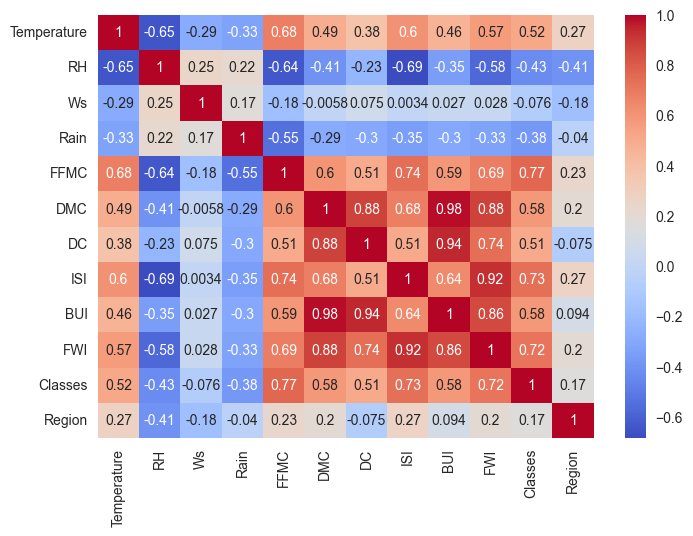

In [109]:
sns.heatmap(df_copy.corr(),annot =True,cmap='coolwarm')

<Axes: ylabel='FWI'>

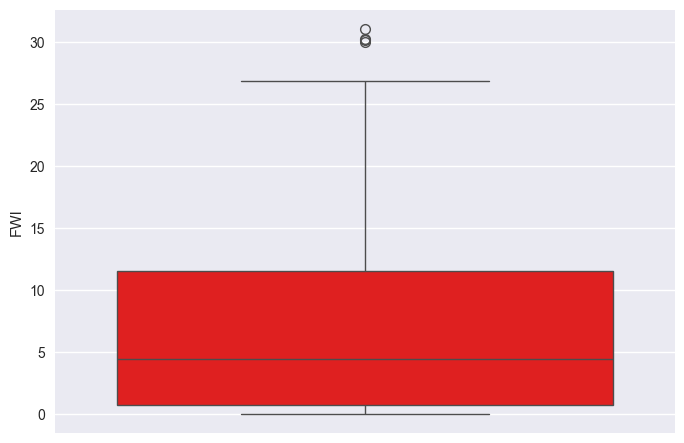

In [111]:
### Box Plots 
sns.boxplot(df["FWI"],color ="red")

In [112]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [129]:
import numpy as np

df["Classes"] = np.where(
    df["Classes"].astype(str).str.contains("not fire", case=False),
    0,
    1
)

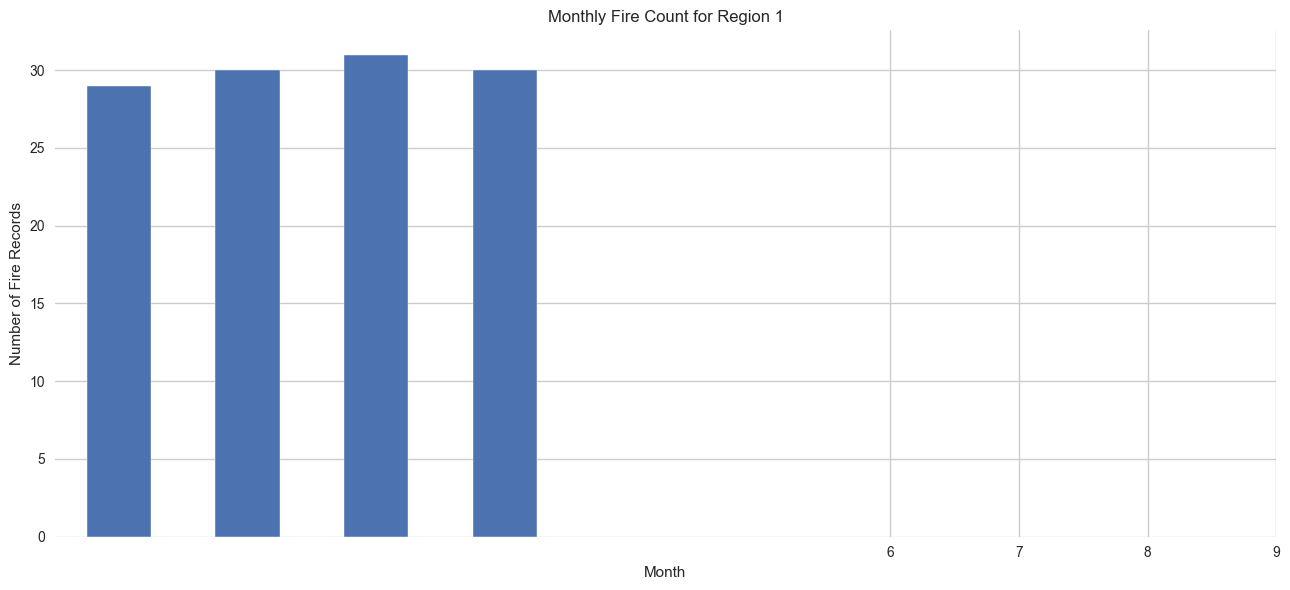

In [131]:
## Monthly Fire analysis
dftemp = df.loc[df["Region"] == 1]
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(13,6))

monthly_counts = dftemp.groupby("month").size()
monthly_counts.plot(kind="bar", ax=ax)

ax.set_title("Monthly Fire Count for Region 1")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Fire Records")
ax.set_xticks(monthly_counts.index)
ax.set_xticklabels(monthly_counts.index, rotation=0)

plt.tight_layout()